# OT/ICS-IDS — Reviewer-Response Experiments (revision v7)

This notebook implements the **additional experimentation** requested by the two
reviewers, on top of the proven v8/v10 pipeline. It is deliberately modular:
each block is guarded by a flag in the **CONFIG** cell so you can run only what
you need, and each block writes its own CSV / figure / LaTeX-table artifacts.

| Block | Reviewer ask | Needs Nebius LLM key? | Output prefix |
|---|---|---|---|
| **REV-A** | R1.1 — deployable hybrid (predicted-class router **+** confidence-gated cascade) on WUSTL 5-class | Yes | `REV_A_hybrid/` |
| **REV-B** | R2.8 — feature-count ablation ($K_{feat}\in\{6,8,10,12,16,20,\text{all}\}$) across model families | Optional (anchors run keyless) | `REV_B_featablation/` |
| **REV-C** | R2.4 — t-SNE / UMAP normal-vs-attack distribution visualizations | No | `REV_C_embeddings/` |
| **REV-D** | R2.5 — complexity table (params, size, inference time, memory, approx FLOPs) | No | `REV_D_complexity/` |
| **REV-E** | R1.2 — cross-campaign (leave-one-attack-type-out) generalisation on WUSTL | Optional | `REV_E_crosscampaign/` |

The shared-pipeline section (cells under **PART 1**) is a faithful condensation
of `ot_ics_ids_llm_nebius_v10_*` (same MI feature selection, same balanced
K-shot split, same RF/XGBoost/TabPFN/TabICL configs, same role-instructed JSON
prompt and label parser, same FAR/DR/MCC metrics). Run PART 1 top-to-bottom
once, then run whichever PART 2 blocks you need.

**Credentials** (Colab Secrets or env vars): `KAGGLE_USERNAME`, `KAGGLE_KEY`
(all blocks), `NEBIUS_API_KEY` (REV-A and the optional LLM arms),
`TABPFN_TOKEN` (TabPFN local/cloud).

## PART 1 — Shared pipeline (condensed from v10)

In [1]:
# ============================================================
# 0) INSTALL & IMPORTS
# ============================================================
!pip install -q "openai>=1.55" tqdm pandas scikit-learn scipy matplotlib seaborn kagglehub tiktoken
!pip install -q xgboost
# Install the TabPFN *cloud client* and TabICL separately. The heavy local `tabpfn`
# package is intentionally NOT installed: the notebook only uses tabpfn_client, and
# local tabpfn pins torch/scikit-learn versions that conflict with tabicl and make
# pip drop both silently under -q.
!pip install -q tabpfn-client
!pip install -q tabicl
!pip install -q umap-learn   # REV-C only; harmless otherwise

import os, sys, json, random, math, hashlib, time, re, gc, glob, zipfile, pickle, tracemalloc
from dataclasses import dataclass, field
from typing import List, Dict, Any, Tuple, Optional
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import warnings, logging
warnings.filterwarnings("ignore")
for _l in ("tabpfn_client", "tabpfn_client.client", "httpx", "httpcore"):
    logging.getLogger(_l).setLevel(logging.ERROR)

sns.set_context("paper", font_scale=1.05)
sns.set_style("whitegrid")

def set_seed(s: int) -> None:
    random.seed(s); np.random.seed(s)

def ensure_dir(p: str) -> str:
    os.makedirs(p, exist_ok=True); return p

def _sha1(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

BASE_OUT = ensure_dir("./ot_ics_ids_revision_outputs")
print("Imports OK. Outputs ->", BASE_OUT)

Imports OK. Outputs -> ./ot_ics_ids_revision_outputs


In [2]:
# ============================================================
# 1) CONFIG  — toggle the reviewer blocks here
# ============================================================
RUN_REV_A_HYBRID        = True    # R1.1  (needs NEBIUS_API_KEY)
RUN_REV_B_FEATABLATION  = True    # R2.8  (anchors keyless; LLM arm optional below)
RUN_REV_C_EMBEDDINGS    = True    # R2.4  (no key)
RUN_REV_D_COMPLEXITY    = True    # R2.5  (no key)
RUN_REV_E_CROSSCAMPAIGN = True    # R1.2  (anchors keyless; LLM arm optional below)
RUN_REV_F_FIG1          = True    # R1.3  (no key; reads result archives in the repo)

# Optional (costly) LLM arms inside otherwise-keyless blocks:
REV_B_INCLUDE_LLM       = True   # adds an LLM arm to the feature-count sweep
REV_E_INCLUDE_LLM       = True   # adds an LLM arm to the cross-campaign probe

# Protocol constants (identical to the paper's E7 headline protocol)
TOP_K_FEATURES   = 12
K_SHOT_PER_CLASS = 10
SEEDS            = [42, 43, 44]
N_LLM_TEST       = 2000           # LLM test-subsample size for REV-A (cost control)
PRIMARY_MODEL    = "Qwen3-235B-A22B"
NORMAL_LABEL     = "Normal"
SUBSAMPLE_PER_CLASS = 50_000

DATASET_SLUGS = {
    "swat":  "vishala28/swat-dataset-secure-water-treatment-system",
    "hai":   "icsdataset/hai-security-dataset",
    "wustl": "annaamalaiu/wustl-iiot-2021-dataset",
}
HAI_VERSION_PREFERENCE = ["hai-22.04","hai-21.03","hai-20.07","hai-1.0","hai-2.0","hai-3.0"]

# REV-F reads the committed result archives, not Kaggle. Point this at the
# root of the fm-security repo (the folder that contains runs/, src/, ...).
REPO_ROOT = os.environ.get("FMSEC_REPO_ROOT", ".")   # e.g. "/content/fm-security"
print("Config loaded. Blocks:",
      {k:v for k,v in dict(A=RUN_REV_A_HYBRID,B=RUN_REV_B_FEATABLATION,
                           C=RUN_REV_C_EMBEDDINGS,D=RUN_REV_D_COMPLEXITY,
                           E=RUN_REV_E_CROSSCAMPAIGN,F=RUN_REV_F_FIG1).items()})

Config loaded. Blocks: {'A': True, 'B': True, 'C': True, 'D': True, 'E': True, 'F': True}


In [14]:
!pip install tabpfn-client

## Local tokens (JupyterLab / non-Colab) — optional manual override

On Colab, leave the fields blank: tokens are read from the Secrets panel (key icon).
When running **locally** (JupyterLab, VS Code, plain Jupyter), paste your tokens in the
cell below — they're pushed into `os.environ`, which every downstream lookup
(`_get_secret`, `_resolve_tabpfn_token`, the REV-B guard, the Nebius client) reads from.
Run this cell *before* the Nebius client cell that follows.

**Security:** values typed here are saved inside the `.ipynb`. Don't commit real tokens
to git; clear them before sharing or exporting the notebook.


In [3]:
# ============================================================
# LOCAL TOKENS  (optional; for JupyterLab / local runs)
# ============================================================
# Leave blank on Colab. Paste values when running locally.
LOCAL_TOKENS = {
    "NEBIUS_API_KEY": "",   # <-- LLM arms (run_llm in REV-A / REV-B / REV-E, REV-D latency)
    "TABPFN_TOKEN": "",   # <-- TabPFN cloud anchor (REV-A / REV-B / REV-D / REV-E)
    "KAGGLE_USERNAME": "",
    "KAGGLE_KEY": "",
}
for _k, _v in LOCAL_TOKENS.items():
    if _v and _v.strip():
        os.environ[_k] = _v.strip()
        print(f"  {_k}: set from LOCAL_TOKENS ({len(_v.strip())} chars)")
    elif os.environ.get(_k):
        print(f"  {_k}: already present in environment")
    else:
        print(f"  {_k}: not set (will fall back to Colab Secrets / existing environment)")

# If the Nebius client was already built on an earlier run, rebuild it so a freshly
# pasted NEBIUS_API_KEY takes effect without re-running the whole notebook. On the
# first top-to-bottom run OpenAI isn't defined yet, so this is skipped and the next
# cell builds the client from the environment we just set.
try:
    if "OpenAI" in globals() and os.environ.get("NEBIUS_API_KEY"):
        client = OpenAI(base_url="https://api.studio.nebius.com/v1/",
                        api_key=os.environ["NEBIUS_API_KEY"])
        print("  Nebius client rebuilt from LOCAL_TOKENS.")
except Exception as _e:
    print(f"  (Nebius client rebuild skipped: {type(_e).__name__})")


  NEBIUS_API_KEY: set from LOCAL_TOKENS (235 chars)
  TABPFN_TOKEN: set from LOCAL_TOKENS (167 chars)
  KAGGLE_USERNAME: set from LOCAL_TOKENS (7 chars)
  KAGGLE_KEY: set from LOCAL_TOKENS (37 chars)


In [4]:
# ============================================================
# 2) NEBIUS LLM CLIENT + REGISTRY  (only needed for LLM arms)
# ============================================================
from openai import OpenAI

def _get_secret(name):
    try:
        from google.colab import userdata
        v = userdata.get(name)
        if v: return v
    except Exception:
        pass
    return os.environ.get(name, "")

NEBIUS_KEY = _get_secret("NEBIUS_API_KEY")
client = OpenAI(base_url="https://api.studio.nebius.com/v1/", api_key=NEBIUS_KEY) if NEBIUS_KEY else None

MODEL_REGISTRY = {
    "Llama-3.3-70B"   : "meta-llama/Llama-3.3-70B-Instruct",
    "Qwen3-235B-A22B" : "Qwen/Qwen3-235B-A22B-Instruct-2507",
    "Hermes-4-70B"    : "NousResearch/Hermes-4-70B",
    "Hermes-4-405B"   : "NousResearch/Hermes-4-405B",
}
# size_b = total params, active_b = active params (MoE), for REV-D complexity table
MODEL_META = {
    "Llama-3.3-70B"   : {"family":"Llama",    "size_b":70,  "active_b":70,   "moe":False},
    "Qwen3-235B-A22B" : {"family":"Qwen3",    "size_b":235, "active_b":22,   "moe":True},
    "Hermes-4-70B"    : {"family":"Hermes-4", "size_b":70,  "active_b":70,   "moe":False},
    "Hermes-4-405B"   : {"family":"Hermes-4", "size_b":405, "active_b":405,  "moe":False},
}
# Nebius public tariff snapshot (USD per 1e6 tokens), matches paper Table 8
PRICING = {
    "Llama-3.3-70B"   : (0.13, 0.40),
    "Qwen3-235B-A22B" : (0.20, 0.60),
    "Hermes-4-70B"    : (0.13, 0.40),
    "Hermes-4-405B"   : (1.00, 3.00),
}

class NebiusLLM:
    def __init__(self, client, model_id, name, temperature=0.0, max_tokens=16, cache_enabled=True):
        self.client=client; self.model_id=model_id; self.name=name
        self.temperature=temperature; self.max_tokens=max_tokens
        self.cache_enabled=cache_enabled and (temperature==0.0); self._cache={}
        self.stats={"name":name,"calls":0,"cached":0,"errors":0,
                    "prompt_tokens":0,"completion_tokens":0,"wall_seconds":0.0}
    def _key(self, system, prompt): return _sha1(f"{self.model_id}|t={self.temperature}|sys={system}|p={prompt}")
    def _one_call(self, prompt, system=None):
        key=self._key(system,prompt)
        if self.cache_enabled and key in self._cache:
            self.stats["cached"]+=1; return self._cache[key]
        msgs=[]; 
        if system: msgs.append({"role":"system","content":system})
        msgs.append({"role":"user","content":prompt})
        for attempt in range(4):
            try:
                t0=time.time()
                resp=self.client.chat.completions.create(model=self.model_id, messages=msgs,
                        temperature=self.temperature, max_tokens=self.max_tokens, n=1)
                dt=time.time()-t0; text=resp.choices[0].message.content.strip()
                self.stats["calls"]+=1; self.stats["wall_seconds"]+=dt
                if getattr(resp,"usage",None):
                    self.stats["prompt_tokens"]+=resp.usage.prompt_tokens
                    self.stats["completion_tokens"]+=resp.usage.completion_tokens
                if self.cache_enabled: self._cache[key]=text
                return text
            except Exception:
                self.stats["errors"]+=1
                if attempt==3: return ""
                time.sleep(min(2**attempt+random.random(),12))
    def chat(self, prompt, system=None, n=1):
        return [self._one_call(prompt, system=system) for _ in range(n)]

print("Nebius client", "READY" if client else "NOT configured (LLM arms will be skipped)")

Nebius client READY


In [5]:
# ============================================================
# 3) KAGGLE AUTH
# ============================================================
for k in ("KAGGLE_USERNAME","KAGGLE_KEY"):
    if not os.environ.get(k):
        v=_get_secret(k)
        if v: os.environ[k]=v
assert os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"), \
    "Set KAGGLE_USERNAME and KAGGLE_KEY (Colab Secrets or env vars)."
print("Kaggle creds loaded.")

Kaggle creds loaded.


In [6]:
# ============================================================
# 4) DATA DOWNLOAD + READ  (Kaggle mirrors; faithful to v10)
# ============================================================
def _download_kaggle(slug):
    import kagglehub
    folder = kagglehub.dataset_download(slug)
    print("  kagglehub ->", folder); return folder

def _all_csvs(folder):
    csvs = sorted(glob.glob(os.path.join(folder,"**","*.csv"), recursive=True))
    return [c for c in csvs if "_macosx" not in c.lower()]

_SWAT_LABEL_CANDS = ("normal/attack","normal_attack","label","attack")
def _swat_label_col(d):
    for col in d.columns:
        if str(col).strip().lower() in _SWAT_LABEL_CANDS: return col
    return None

def _read_swat(folder):
    # This Kaggle mirror ships three same-schema files: attack.csv (Attack only),
    # normal.csv and merged.csv (Normal). Column names differ by stray whitespace
    # across files (e.g. "MV101" vs "MV101 "), so a naive concat splits each sensor
    # into two half-populated columns -> the ~0.688 NaN that emptied the frame.
    # Fix: strip names per file, then either use a single file that already holds
    # both classes, or take the densest file PER class so Normal AND Attack survive.
    csvs=_all_csvs(folder)
    def _try(path):
        for sep in (",",";"):
            for enc in ("utf-8","latin-1"):
                try:
                    df=pd.read_csv(path, sep=sep, encoding=enc, low_memory=False)
                    if df.shape[1]>=5: return df
                except Exception: continue
        return pd.read_csv(path, sep=";", decimal=",", encoding="latin-1", low_memory=False)
    parsed=[]
    for c in csvs:
        df=_try(c); df.columns=[str(x).strip() for x in df.columns]   # align names across files
        df["_source_file"]=os.path.basename(c); parsed.append(df)
    def _nclasses(d):
        lc=_swat_label_col(d)
        return d[lc].astype(str).str.strip().nunique() if lc is not None else 0
    multi=[d for d in parsed if _nclasses(d)>=2]
    if multi:
        keep=[max(multi, key=len)]                       # a combined file already has both classes
    else:
        bycls={}
        for d in parsed:                                  # one densest file per single-class file
            lc=_swat_label_col(d)
            if lc is None: continue
            cls=d[lc].astype(str).str.strip().mode().iloc[0]
            if cls not in bycls or len(d)>len(bycls[cls]): bycls[cls]=d
        keep=list(bycls.values())
    out=pd.concat(keep, ignore_index=True)
    print(f"  [swat] using {[d['_source_file'].iloc[0] for d in keep]} -> shape={out.shape}")
    return out

def _read_hai(folder):
    subdirs=[d for d in glob.glob(os.path.join(folder,"*")) if os.path.isdir(d)]
    chosen=None
    for pref in HAI_VERSION_PREFERENCE:
        for d in subdirs:
            if pref in os.path.basename(d).lower().replace("_","-"): chosen=d; break
        if chosen: break
    chosen=chosen or folder
    csvs=[c for c in _all_csvs(chosen) if "haiend" not in os.path.basename(c).lower()
                                         and "hai-end" not in os.path.basename(c).lower()]
    dfs=[]
    for c in csvs:
        df=pd.read_csv(c, low_memory=False); df["_source_file"]=os.path.basename(c); dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

def _read_wustl(folder):
    csvs=_all_csvs(folder); dfs=[]
    for c in csvs:
        df=pd.read_csv(c, low_memory=False); df["_source_file"]=os.path.basename(c); dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

READERS={"swat":_read_swat,"hai":_read_hai,"wustl":_read_wustl}
print("Readers ready.")

Readers ready.


In [7]:
# ============================================================
# 5) PREPROCESS  (binary + WUSTL multi-class)  faithful to v10
# ============================================================
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

SWAT_LABEL_CANDIDATES=["Normal/Attack","Normal_Attack","label","Label","Attack"]
HAI_LABEL_CANDIDATES =["Attack","attack","label","Label"]
# WUSTL leakage columns flagged by the dataset authors
WUSTL_LEAKAGE=["StartTime","LastTime","SrcAddr","DstAddr","sIpId","dIpId"]

def _find_label_column(df, cands):
    for c in cands:
        for col in df.columns:
            if col.strip().lower()==c.strip().lower(): return col
    return None

def _basic_clean_numeric(df, label_col, max_col_nan=0.5):
    df=df.copy()
    df.columns=[str(c).strip() for c in df.columns]      # kill stray whitespace in names
    label_col=str(label_col).strip()
    feats=[c for c in df.columns if c!=label_col and not c.startswith("_")]
    for col in feats: df[col]=pd.to_numeric(df[col], errors="coerce")
    df=df.replace([np.inf,-np.inf],np.nan)
    # Drop feature columns that are mostly empty (non-numeric, e.g. ' Timestamp', or
    # file-exclusive after a multi-file concat) BEFORE the row-wise dropna -- otherwise
    # how="any" can remove every row.
    sparse=[c for c in feats if df[c].isna().mean()>max_col_nan]
    if sparse: df=df.drop(columns=sparse); feats=[c for c in feats if c not in sparse]
    df=df.dropna(subset=feats, how="any")
    nun=df[feats].nunique(); const=nun[nun<=1].index.tolist()
    if const: df=df.drop(columns=const)
    return df

def preprocess_swat(df, binary=True):
    lc=_find_label_column(df, SWAT_LABEL_CANDIDATES)
    df=df.rename(columns={lc:"Label"})
    drop=[c for c in df.columns if c!="Label" and (c.startswith("_") or
          c.lower() in ("timestamp","time","datetime","date","unnamed: 0"))]
    df=df.drop(columns=drop, errors="ignore")
    df["Label"]=(df["Label"].astype(str).str.strip()
                 .str.replace(r"\s+","",regex=True)
                 .str.replace(r"[^A-Za-z]","",regex=True).str.title())
    df.loc[df["Label"]!="Normal","Label"]="Attack"   # SWaT mirror is binary-only
    return _basic_clean_numeric(df,"Label")

def preprocess_hai(df, binary=True):
    lc=_find_label_column(df, HAI_LABEL_CANDIDATES)
    if lc is not None:
        df=df.rename(columns={lc:"_lab"})
        df["Label"]=df["_lab"].astype(str).str.strip().map(
            lambda v:"Normal" if v in ("0","0.0","Normal","normal","False","false","nan","") else "Attack")
        df=df.drop(columns=["_lab"])
    else:
        per=[c for c in df.columns if c.lower().startswith("attack_p")]
        att=(df[per].astype(float).sum(axis=1)>0)
        df["Label"]=np.where(att,"Attack","Normal"); df=df.drop(columns=per)
    drop=[c for c in df.columns if c!="Label" and (c.startswith("_") or
          c.lower() in ("timestamp","time","datetime","date","unnamed: 0"))]
    df=df.drop(columns=drop, errors="ignore")
    return _basic_clean_numeric(df,"Label")

def _wustl_pick_binary_col(df):
    for cand in ("Target","Label","label"):
        for col in df.columns:
            if col.lower()==cand.lower():
                vals=pd.to_numeric(df[col], errors="coerce").dropna()
                if len(vals) and set(np.unique(vals)).issubset({0,1}): return col
    return None

def _wustl_pick_categorical_col(df):
    for cand in ("Traffic","Attack","Category","attack_cat"):
        for col in df.columns:
            if col.lower()==cand.lower() and df[col].dtype==object: return col
    return None

def preprocess_wustl(df, binary=True):
    df=df.drop(columns=[c for c in df.columns
                        if c in WUSTL_LEAKAGE or c.startswith("_")], errors="ignore")
    if binary:
        bc=_wustl_pick_binary_col(df)
        cat=_wustl_pick_categorical_col(df)
        df=df.rename(columns={bc:"_bin"})
        df["Label"]=np.where(pd.to_numeric(df["_bin"],errors="coerce").fillna(0).astype(int)==0,
                             "Normal","Attack")
        df=df.drop(columns=[c for c in ["_bin",cat] if c and c in df.columns], errors="ignore")
    else:
        cat=_wustl_pick_categorical_col(df); bc=_wustl_pick_binary_col(df)
        df=df.rename(columns={cat:"Label"})
        df["Label"]=df["Label"].astype(str).str.strip()
        # canonicalise to the 5-class taxonomy used in the paper
        cmap={"normal":"Normal","dos":"DoS","denialofservice":"DoS",
              "recon":"Reconn","reconnaissance":"Reconn","scan":"Reconn",
              "command":"CommInj","commandinjection":"CommInj","comminj":"CommInj",
              "injection":"CommInj","backdoor":"Backdoor"}
        df["Label"]=df["Label"].map(lambda v: cmap.get(re.sub(r"[^a-z]","",v.lower()), v))
        df=df.drop(columns=[bc] if bc and bc in df.columns else [], errors="ignore")
    return _basic_clean_numeric(df,"Label")

PREPROC={"swat":preprocess_swat,"hai":preprocess_hai,"wustl":preprocess_wustl}
print("Preprocessors ready.")

Preprocessors ready.


In [8]:
# ============================================================
# 6) LOAD + PREPARE  (download->read->preprocess->subsample->tag)
# ============================================================
_RAW_CACHE = {}   # (ds,binary) -> processed df

def load_processed(ds, binary=True):
    key=(ds,binary)
    if key in _RAW_CACHE: return _RAW_CACHE[key].copy()
    folder=_download_kaggle(DATASET_SLUGS[ds])
    raw=READERS[ds](folder)
    df=PREPROC[ds](raw, binary=binary).reset_index(drop=True)
    df["_row_idx"]=np.arange(len(df), dtype=np.int64)
    # per-class cap for tractability (random_state=0 -> matches v8/paper)
    if df["Label"].value_counts().max()>SUBSAMPLE_PER_CLASS:
        df=df.groupby("Label", group_keys=False).apply(
            lambda g: g.sample(min(len(g),SUBSAMPLE_PER_CLASS), random_state=0)
        ).reset_index(drop=True)
    print(f"[{ds} binary={binary}] shape={df.shape}  classes={df['Label'].value_counts().to_dict()}")
    _RAW_CACHE[key]=df
    return df.copy()

def select_top_features(df, k=TOP_K_FEATURES, sample=50_000, seed=0):
    rng=np.random.default_rng(seed)
    sub=df.iloc[rng.choice(len(df), size=min(sample,len(df)), replace=False)] if len(df)>sample else df
    X=sub.drop(columns=["Label","_row_idx"], errors="ignore").select_dtypes(include=[np.number])
    y=LabelEncoder().fit_transform(sub["Label"])
    mi=mutual_info_classif(X, y, random_state=seed)
    order=np.argsort(mi)[::-1]
    if k=="all" or k>=X.shape[1]:
        return list(X.columns[order])
    return list(X.columns[order[:k]])

def build_icl_test_split(df, features, n_icl_per_class, n_test_per_class=-1, seed=0):
    cols=features+["Label"]; rng=np.random.default_rng(seed)
    icl,test=[],[]
    for cls,sub in df.groupby("Label"):
        idx=rng.permutation(len(sub)); sub=sub.iloc[idx]
        icl.append(sub.iloc[:n_icl_per_class][cols])
        rest=sub.iloc[n_icl_per_class:]
        if n_test_per_class>0: rest=rest.iloc[:n_test_per_class]
        test.append(rest[cols])
    icl =pd.concat(icl ,ignore_index=True).sample(frac=1,random_state=seed).reset_index(drop=True)
    test=pd.concat(test,ignore_index=True).sample(frac=1,random_state=seed).reset_index(drop=True)
    return icl,test
print("Loaders + MI selection + balanced split ready.")

Loaders + MI selection + balanced split ready.


In [9]:
# ============================================================
# 7) METRICS  (FAR / DR / MCC, multi-class safe; faithful to v10)
# ============================================================
from sklearn.metrics import (precision_recall_fscore_support, accuracy_score,
                             balanced_accuracy_score, matthews_corrcoef)

def metrics_from_predictions(y_true, y_pred, classes=None, normal_label=NORMAL_LABEL):
    y_true=np.asarray(y_true)
    y_pred=np.asarray([p if p is not None else "<NONE>" for p in y_pred])
    if classes is None: classes=sorted(set(y_true.tolist()))
    p,rec,f,sup=precision_recall_fscore_support(y_true,y_pred,labels=classes,
                                                average=None,zero_division=0)
    try: mcc=matthews_corrcoef(y_true,y_pred)
    except Exception: mcc=float("nan")
    nmask=(y_true==normal_label); amask=(y_true!=normal_label)
    far=float((y_pred[nmask]!=normal_label).sum()/nmask.sum()) if nmask.sum() else float("nan")
    dr =float((y_pred[amask]!=normal_label).sum()/amask.sum()) if amask.sum() else float("nan")
    per={c:{"precision":float(p[i]),"recall":float(rec[i]),"f1":float(f[i]),"support":int(sup[i])}
         for i,c in enumerate(classes)}
    return {"accuracy":float(accuracy_score(y_true,y_pred)),
            "balanced_accuracy":float(balanced_accuracy_score(y_true,y_pred)),
            "macro_f1":float(f.mean() if len(f) else 0.0),"mcc":float(mcc),
            "false_alarm_rate":far,"detection_rate":dr,"per_class":per,"classes":classes}
print("Metrics ready.")

Metrics ready.


In [10]:
# ============================================================
# 8) TABULAR ANCHORS  (RF, XGBoost, TabPFN cloud, TabICL) + timing/memory
# ============================================================
from sklearn.ensemble import RandomForestClassifier

def _resolve_tabpfn_token():
    if os.environ.get("TABPFN_TOKEN"): return os.environ["TABPFN_TOKEN"]
    tok=_get_secret("TABPFN_TOKEN")
    if tok: os.environ["TABPFN_TOKEN"]=tok; return tok
    return None

def _timed_fit_predict(make, Xtr, ytr, Xte):
    """Return (yhat, proba, classes_, fit_s, pred_s, peak_mem_mb, model)."""
    tracemalloc.start()
    t0=time.time(); clf=make(); clf.fit(Xtr,ytr); fit_s=time.time()-t0
    t1=time.time(); yhat=clf.predict(Xte); pred_s=time.time()-t1
    try: proba=clf.predict_proba(Xte); classes_=list(clf.classes_)
    except Exception: proba,classes_=None,None
    _,peak=tracemalloc.get_traced_memory(); tracemalloc.stop()
    return yhat, proba, classes_, fit_s, pred_s, peak/1e6, clf

def anchor_rf(Xtr,ytr,Xte):
    return _timed_fit_predict(lambda: RandomForestClassifier(
        n_estimators=200, max_features="sqrt", class_weight="balanced",
        random_state=0, n_jobs=-1), Xtr,ytr,Xte)

def anchor_xgb(Xtr,ytr,Xte):
    from xgboost import XGBClassifier
    le=LabelEncoder(); ytr_e=le.fit_transform(ytr)
    multi=len(le.classes_)>2
    def make():
        return XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric=("mlogloss" if multi else "logloss"),
            tree_method="hist", n_jobs=-1, random_state=0)
    tracemalloc.start()
    t0=time.time(); clf=make(); clf.fit(Xtr,ytr_e); fit_s=time.time()-t0
    t1=time.time(); yhat_e=clf.predict(Xte); pred_s=time.time()-t1
    try: proba=clf.predict_proba(Xte); classes_=list(le.classes_)
    except Exception: proba,classes_=None,None
    _,peak=tracemalloc.get_traced_memory(); tracemalloc.stop()
    return le.inverse_transform(yhat_e), proba, classes_, fit_s, pred_s, peak/1e6, clf

def anchor_tabpfn(Xtr,ytr,Xte, max_rows=10_000):
    # K-shot headline regime uses the full (small) ICL set; max-ctx caps at 10k
    if len(Xtr)>max_rows:
        idx=np.random.default_rng(0).choice(len(Xtr),max_rows,replace=False)
        Xtr,ytr=Xtr[idx],ytr[idx]
    _resolve_tabpfn_token()
    from tabpfn_client import TabPFNClassifier as TabPFNCloud
    return _timed_fit_predict(lambda: TabPFNCloud(), Xtr,ytr,Xte)

def anchor_tabicl(Xtr,ytr,Xte):
    from tabicl import TabICLClassifier
    def make():
        try:
            return TabICLClassifier(n_estimators=16, norm_methods=["none","power"],
                                    outlier_threshold=4.0, softmax_temperature=0.9,
                                    random_state=0, device="cpu")
        except TypeError:
            return TabICLClassifier(random_state=0)
    return _timed_fit_predict(make, Xtr,ytr,Xte)

ANCHOR_FNS={"RandomForest":anchor_rf,"XGBoost":anchor_xgb,
            "TabPFN":anchor_tabpfn,"TabICL":anchor_tabicl}

def fit_anchor(name, icl_df, test_df, features, **kw):
    Xtr=icl_df[features].values; ytr=icl_df["Label"].values
    Xte=test_df[features].values; yte=test_df["Label"].values
    yhat,proba,classes_,fit_s,pred_s,mem,model=ANCHOR_FNS[name](Xtr,ytr,Xte, **(
        {"max_rows":kw.get("max_rows",10_000)} if name=="TabPFN" else {}))
    m=metrics_from_predictions(yte,yhat,classes=sorted(set(yte.tolist())),normal_label=NORMAL_LABEL)
    m.update({"y_true":list(yte),"y_pred":list(yhat),"y_proba":proba,"classes_":classes_,
              "fit_s":fit_s,"pred_s":pred_s,"peak_mem_mb":mem,"model_obj":model,"name":name})
    return m
print("Anchors ready:", list(ANCHOR_FNS))

Anchors ready: ['RandomForest', 'XGBoost', 'TabPFN', 'TabICL']


In [11]:
# ============================================================
# 9) LLM PROMPT + LABEL PARSE + PARALLEL RUNNER  (role-instructed JSON)
# ============================================================
from concurrent.futures import ThreadPoolExecutor, as_completed

ROLE_SYSTEM = {
 "swat":("You are a senior process-control engineer monitoring a six-stage "
         "water-treatment plant. Channels: LIT=level transmitters, FIT=flow "
         "transmitters, AIT=analyzer transmitters, PIT=pressure transmitters, "
         "MV/P/UV=valves/pumps/UV lamps."),
 "hai":("You are a control-room operator monitoring a hardware-in-the-loop "
        "industrial process with four interconnected subsystems (P1 turbine, "
        "P2 boiler, P3 water-treatment, P4 HIL simulator)."),
 "wustl":("You are a network and ICS cybersecurity analyst monitoring an "
          "Industrial IoT testbed running Modbus/TCP traffic. Each row is a "
          "network flow summarised by packet/byte counts, rates, TTLs, ports."),
}

def build_prompt(icl_df, query_row, features, labels, ds):
    sys=(ROLE_SYSTEM[ds]+f"\nClassify each row as one of: {', '.join(labels)}. "
         "Respond with exactly one label and nothing else.")
    lines=[]
    for _,r in icl_df.iterrows():
        obj={f:(round(float(r[f]),4) if isinstance(r[f],(int,float,np.floating)) else r[f]) for f in features}
        lines.append(json.dumps(obj)+" -> "+str(r["Label"]))
    q={f:(round(float(query_row[f]),4) if isinstance(query_row[f],(int,float,np.floating)) else query_row[f]) for f in features}
    user="Examples:\n"+"\n".join(lines)+"\n\nQuery:\n"+json.dumps(q)+" ->"
    return sys,user

def extract_label(text, labels):
    if not text: return None
    t=text.strip()
    for lab in sorted(labels,key=len,reverse=True):
        if re.search(r"\b"+re.escape(lab)+r"\b", t, re.I): return lab
    low=t.lower()
    for lab in labels:
        if lab.lower() in low: return lab
    return None

def run_llm(model_name, icl_df, test_df, features, ds, max_workers=8, verbose=True):
    assert client is not None, "NEBIUS_API_KEY not set."
    labels=sorted(icl_df["Label"].unique().tolist())
    llm=NebiusLLM(client, MODEL_REGISTRY[model_name], name=model_name,
                  temperature=0.0, max_tokens=16, cache_enabled=False)
    rows=list(test_df.iterrows()); results=[None]*len(rows)
    def _proc(ir):
        i,(idx,row)=ir
        sysm,userm=build_prompt(icl_df,row,features,labels,ds)
        txt=llm.chat(userm, system=sysm, n=1)[0]
        lab=extract_label(txt,labels)
        if lab is None:
            txt=llm.chat(userm+"\n(Reply with exactly one label.)", system=sysm, n=1)[0]
            lab=extract_label(txt,labels)
        return i,(lab if lab is not None else None),row["Label"]
    t0=time.time()
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs={ex.submit(_proc,(i,ir)):i for i,ir in enumerate(rows)}
        pbar=tqdm(total=len(rows),desc=f"{model_name}|{ds}") if verbose else None
        for fut in as_completed(futs):
            i,lab,tr=fut.result(); results[i]=(lab,tr)
            if pbar: pbar.update(1)
        if pbar: pbar.close()
    y_pred=[r[0] for r in results]; y_true=[r[1] for r in results]
    classes=sorted(set([c for c in y_true]))
    m=metrics_from_predictions(y_true,y_pred,classes=classes,normal_label=NORMAL_LABEL)
    # impute unparseable -> conservative (Attack / most-common attack) as in paper
    fallback="Attack" if set(labels)=={"Normal","Attack"} else \
        Counter([t for t in y_true if t!=NORMAL_LABEL]).most_common(1)[0][0]
    y_pred_imp=[p if p is not None else fallback for p in y_pred]
    m_imp=metrics_from_predictions(y_true,y_pred_imp,classes=classes,normal_label=NORMAL_LABEL)
    m_imp.update({"y_true":y_true,"y_pred":y_pred_imp,"y_pred_raw":y_pred,
                  "stats":dict(llm.stats),"elapsed_s":time.time()-t0,"name":model_name,
                  "parse_rate":float(np.mean([p is not None for p in y_pred]))})
    return m_imp
print("LLM runner ready.")

LLM runner ready.


## PART 2 — Reviewer experiment blocks

### REV-A (R1.1) — Deployable hybrid: predicted-class router + confidence-gated cascade

The existing E8 stage in the v10 notebooks is an **oracle** router (it consults
the ground-truth label to choose RF vs LLM) and is explicitly diagnostic. This
block replaces it with two **deployable** hybrids on the WUSTL 5-class taxonomy,
exactly as Reviewer 1 suggests:

1. **Predicted-class router** — route a sample to the LLM only when the tabular
   model *predicts* a rare class (`Backdoor`/`CommInj`), where the LLM is
   competitive; keep the tabular prediction otherwise.
2. **Confidence-gated cascade** — run the tabular model first; escalate to the
   LLM only when the tabular max-probability confidence falls below a threshold
   $\tau$. Sweeping $\tau$ traces a macro-F1 vs LLM-query-budget curve, showing
   how much of the per-class gain is recoverable while querying the LLM on only
   a small fraction of traffic (the cost lever).

In [12]:
# ============================================================
# REV-A — deployable hybrid on WUSTL multiclass
# ============================================================
def _stratified_subsample(df, n_total, seed):
    rng=np.random.default_rng(seed); classes=df["Label"].unique()
    per=max(1, n_total//len(classes)); out=[]
    for c in classes:
        sub=df[df["Label"]==c]
        out.append(sub.iloc[rng.choice(len(sub),min(len(sub),per),replace=False)])
    return pd.concat(out).sample(frac=1,random_state=seed).reset_index(drop=True)

if RUN_REV_A_HYBRID and client is not None:
    OUT=ensure_dir(os.path.join(BASE_OUT,"REV_A_hybrid"))
    RARE={"Backdoor","CommInj"}
    TAUS=[0.0,0.5,0.6,0.7,0.8,0.9,0.95,1.0]
    CASCADE_BASE="RandomForest"   # tabular model that gates escalation
    router_rows=[]; cascade_rows=[]; standalone_rows=[]
    for seed in SEEDS:
        set_seed(seed)
        df=load_processed("wustl", binary=False)
        feats=select_top_features(df, k=TOP_K_FEATURES, seed=seed)
        icl,test_full=build_icl_test_split(df,feats,K_SHOT_PER_CLASS,seed=seed)
        test=_stratified_subsample(test_full, N_LLM_TEST, seed)
        labels=sorted(df["Label"].unique().tolist())

        rf=fit_anchor(CASCADE_BASE, icl, test, feats)
        llm=run_llm(PRIMARY_MODEL, icl, test, feats, "wustl", verbose=False)
        yte=np.array(rf["y_true"])
        rf_pred=np.array(rf["y_pred"]); llm_pred=np.array(llm["y_pred"])
        # align proba -> per-sample confidence + per-sample argmax label
        proba=rf["y_proba"]; cls=rf["classes_"]
        conf=proba.max(axis=1)

        # standalone references
        for nm,pred in [(CASCADE_BASE,rf_pred),(PRIMARY_MODEL,llm_pred)]:
            m=metrics_from_predictions(yte,pred,classes=labels)
            standalone_rows.append(dict(seed=seed,method=nm,macro_f1=m["macro_f1"],
                mcc=m["mcc"],**{f"f1_{c}":m["per_class"][c]["f1"] for c in labels}))

        # --- Hybrid 1: predicted-class router (RF default, LLM on predicted-rare) ---
        route_to_llm=np.array([p in RARE for p in rf_pred])
        hyb=np.where(route_to_llm, llm_pred, rf_pred)
        m=metrics_from_predictions(yte,hyb,classes=labels)
        router_rows.append(dict(seed=seed,llm_query_frac=float(route_to_llm.mean()),
            macro_f1=m["macro_f1"],mcc=m["mcc"],
            **{f"f1_{c}":m["per_class"][c]["f1"] for c in labels}))

        # --- Hybrid 2: confidence-gated cascade ---
        for tau in TAUS:
            escalate=conf<tau
            casc=np.where(escalate, llm_pred, rf_pred)
            m=metrics_from_predictions(yte,casc,classes=labels)
            cascade_rows.append(dict(seed=seed,tau=tau,escalation_frac=float(escalate.mean()),
                macro_f1=m["macro_f1"],mcc=m["mcc"],
                **{f"f1_{c}":m["per_class"][c]["f1"] for c in labels}))
    router_df=pd.DataFrame(router_rows); cascade_df=pd.DataFrame(cascade_rows)
    standalone_df=pd.DataFrame(standalone_rows)
    router_df.to_csv(os.path.join(OUT,"reva_router.csv"),index=False)
    cascade_df.to_csv(os.path.join(OUT,"reva_cascade.csv"),index=False)
    standalone_df.to_csv(os.path.join(OUT,"reva_standalone.csv"),index=False)
    print("=== REV-A standalone (seed mean) ===")
    print(standalone_df.groupby("method")[["macro_f1","mcc"]].mean().round(4))
    print("\n=== REV-A predicted-class router (seed mean) ===")
    print(router_df.mean(numeric_only=True).round(4).to_dict())
    print("\n=== REV-A confidence cascade (seed mean by tau) ===")
    print(cascade_df.groupby("tau")[["escalation_frac","macro_f1","f1_Backdoor","f1_CommInj"]]
          .mean().round(4))
else:
    print("REV-A skipped (flag off or no NEBIUS_API_KEY).")

[wustl binary=False] shape=(108711, 43)  classes={'DoS': 50000, 'Normal': 50000, 'Reconn': 8240, 'CommInj': 259, 'Backdoor': 212}
=== REV-A standalone (seed mean) ===
                 macro_f1     mcc
method                           
Qwen3-235B-A22B    0.9345  0.9341
RandomForest       0.9379  0.9392

=== REV-A predicted-class router (seed mean) ===
{'seed': 43.0, 'llm_query_frac': 0.2744, 'macro_f1': 0.9383, 'mcc': 0.9396, 'f1_Backdoor': 0.8546, 'f1_CommInj': 0.9079, 'f1_DoS': 0.9664, 'f1_Normal': 0.9776, 'f1_Reconn': 0.9849}

=== REV-A confidence cascade (seed mean by tau) ===
      escalation_frac  macro_f1  f1_Backdoor  f1_CommInj
tau                                                     
0.00           0.0000    0.9379       0.8448      0.9123
0.50           0.0634    0.9448       0.8685      0.9223
0.60           0.0997    0.9384       0.8522      0.9181
0.70           0.1896    0.9375       0.8505      0.9146
0.80           0.2905    0.9351       0.8468      0.9104
0.90          

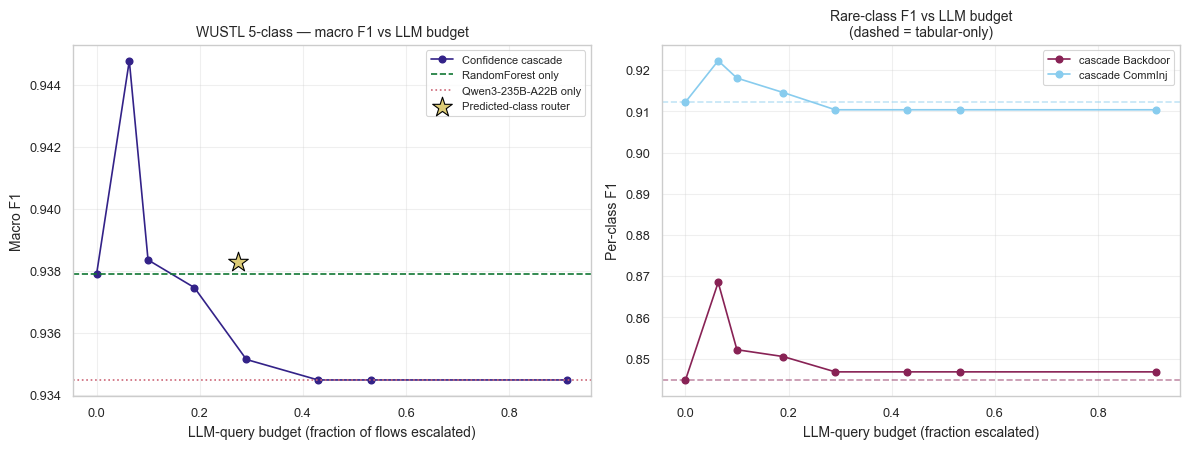

Saved REV-A cascade figure.


In [13]:
# ============================================================
# REV-A — figure: cascade macro-F1 & rare-class F1 vs LLM-query budget
# ============================================================
if RUN_REV_A_HYBRID and client is not None and len(cascade_df):
    g=cascade_df.groupby("tau").mean(numeric_only=True).reset_index().sort_values("escalation_frac")
    sa=standalone_df.groupby("method").mean(numeric_only=True)
    fig,axes=plt.subplots(1,2,figsize=(12,4.6))
    # Panel 1: macro-F1 vs escalation budget
    ax=axes[0]
    ax.plot(g["escalation_frac"],g["macro_f1"],"o-",color="#332288",label="Confidence cascade")
    ax.axhline(sa.loc[CASCADE_BASE,"macro_f1"],ls="--",color="#117733",label=f"{CASCADE_BASE} only")
    ax.axhline(sa.loc[PRIMARY_MODEL,"macro_f1"],ls=":",color="#CC6677",label=f"{PRIMARY_MODEL} only")
    rr=router_df.mean(numeric_only=True)
    ax.scatter([rr["llm_query_frac"]],[rr["macro_f1"]],marker="*",s=220,color="#DDCC77",
               edgecolor="black",zorder=5,label="Predicted-class router")
    ax.set_xlabel("LLM-query budget (fraction of flows escalated)")
    ax.set_ylabel("Macro F1"); ax.set_title("WUSTL 5-class — macro F1 vs LLM budget")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    # Panel 2: rare-class F1 vs escalation budget
    ax=axes[1]
    for c,col in [("Backdoor","#882255"),("CommInj","#88CCEE")]:
        ax.plot(g["escalation_frac"],g[f"f1_{c}"],"o-",color=col,label=f"cascade {c}")
        ax.axhline(sa.loc[CASCADE_BASE,f"f1_{c}"],ls="--",color=col,alpha=0.5)
    ax.set_xlabel("LLM-query budget (fraction escalated)")
    ax.set_ylabel("Per-class F1"); ax.set_title("Rare-class F1 vs LLM budget\n(dashed = tabular-only)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT,"reva_cascade_curve.png"),dpi=160,bbox_inches="tight")
    plt.savefig(os.path.join(OUT,"reva_cascade_curve.pdf"),bbox_inches="tight")
    plt.show()
    print("Saved REV-A cascade figure.")

### REV-B (R2.8) — Feature-count ablation across model families

Sweeps the mutual-information feature budget $K_{feat}\in\{6,8,10,12,16,20,\text{all}\}$
and re-fits every anchor at each budget on each dataset, recording MCC and macro
F1. This shows whether the paper's fixed $K_{feat}=12$ choice advantages any
family. Set `REV_B_INCLUDE_LLM=True` in CONFIG to add an LLM arm at a subset of
budgets (costs API tokens).

In [20]:
def _stratified_subsample(df, n, seed=42, label_col="Label"):

    if len(df) <= n:
        return df.copy()

    frac = n / len(df)

    parts = []
    for _, g in df.groupby(label_col):
        k = max(1, int(round(len(g) * frac)))
        k = min(k, len(g))
        parts.append(g.sample(n=k, random_state=seed))

    out = pd.concat(parts)

    if len(out) > n:
        out = out.sample(n=n, random_state=seed)

    return out.reset_index(drop=True)

In [19]:
print(test.columns.tolist())

['AIT402', 'AIT501', 'AIT502', 'PIT502', 'PIT501', 'PIT503', 'FIT503', 'AIT202', 'Label']


  TABPFN_TOKEN found in environment.
  REV-B anchors: ['RandomForest', 'XGBoost', 'TabPFN', 'TabICL']
00:00 Fitting... Done!
00:01 Predicting... Done!
00:01 Predicting... Done!
00:00 Fitting... Done!
00:01 Predicting... Done!
00:01 Predicting... Done!
00:03 Fitting... Done!
00:05 Predicting... Done!
00:01 Predicting... Done!
00:03 Fitting... Done!
00:04 Predicting... Done!
00:01 Predicting... Done!
00:03 Fitting... Done!
00:04 Predicting... Done!
00:01 Predicting... Done!
00:11 Fitting... Done!
00:02 Predicting... Done!
00:01 Predicting... Done!
00:06 Fitting... Done!
00:02 Predicting... Done!
00:01 Predicting... Done!
00:01 Fitting... Done!
00:04 Predicting... Done!
00:01 Predicting... Done!
00:01 Fitting... Done!
00:05 Predicting... Done!
00:01 Predicting... Done!
00:01 Fitting... Done!
00:02 Predicting... Done!
00:01 Predicting... Done!
00:03 Fitting... Done!
00:05 Predicting... Done!
00:01 Predicting... Done!
00:02 Fitting... Done!
00:06 Predicting... Done!
00:01 Predicting... Done

100%|████████████████████████████████████████| 798M/798M [00:24<00:00, 33.8MB/s]

Extracting files...


  kagglehub -> /Users/dezarzaycubero/.cache/kagglehub/datasets/icsdataset/hai-security-dataset/versions/10
[hai binary=True] shape=(62030, 72)  classes={'Normal': 50000, 'Attack': 12030}
00:01 Fitting... Done!
00:05 Predicting... Done!
00:01 Predicting... Done!
00:01 Fitting... Done!
00:05 Predicting... Done!
00:01 Predicting... Done!
00:01 Fitting... Done!
00:03 Predicting... Done!
00:01 Predicting... Done!
00:05 Fitting... Done!
00:02 Predicting... Done!
00:01 Predicting... Done!
00:01 Fitting... Done!
00:04 Predicting... Done!
00:01 Predicting... Done!
00:01 Fitting... Done!
00:02 Predicting... Done!
00:01 Predicting... Done!
00:04 Fitting... Done!
00:02 Predicting... Done!
00:01 Predicting... Done!
00:03 Fitting... Done!
00:03 Predicting... Done!
00:01 Predicting... Done!
00:01 Fitting... Done!
00:02 Predicting... Done!
00:01 Predicting... Done!
00:01 Fitting... Done!
00:03 Predicting... Done!
00:01 Predicting... Done!
00:01 Fitting... Done!
00:02 Predicting... Done!
00:01 Predicti

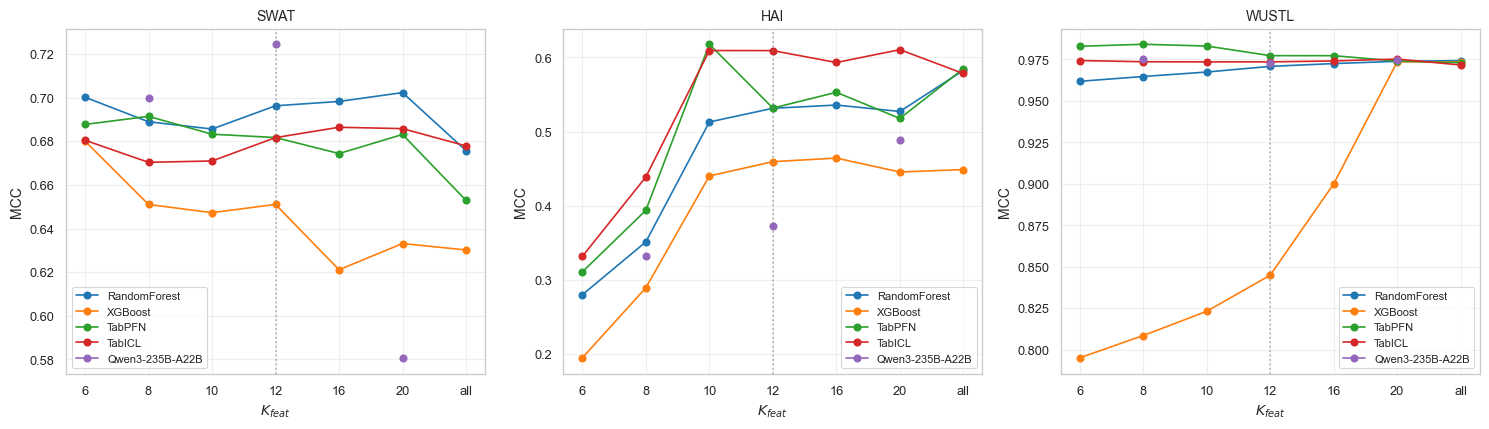

dataset  model            k_feat
hai      Qwen3-235B-A22B  12        0.373
                          20        0.489
                          8         0.331
         RandomForest     10        0.513
                          12        0.531
                          16        0.536
                          20        0.527
                          6         0.280
                          8         0.351
                          all       0.583
         TabICL           10        0.609
                          12        0.609
                          16        0.593
                          20        0.610
                          6         0.331
                          8         0.439
                          all       0.578
         TabPFN           10        0.618
                          12        0.532
                          16        0.553
                          20        0.518
                          6         0.310
                          8         0.394
 

In [21]:
# ============================================================
# REV-B — feature-count ablation
# ============================================================
if RUN_REV_B_FEATABLATION:

    OUT = ensure_dir(os.path.join(BASE_OUT, "REV_B_featablation"))

    K_GRID = [6, 8, 10, 12, 16, 20, "all"]
    LLM_K_SUBSET = [8, 12, 20]

    # --------------------------------------------------------
    # TabPFN authentication
    # --------------------------------------------------------
    _tabpfn_ok = bool(os.environ.get("TABPFN_TOKEN"))

    if _tabpfn_ok:
        print("  TABPFN_TOKEN found in environment.")
    else:
        try:
            from google.colab import userdata
            _tok = userdata.get("TABPFN_TOKEN")
            if _tok:
                os.environ["TABPFN_TOKEN"] = _tok
                _tabpfn_ok = True
                print("  TABPFN_TOKEN loaded from Colab secrets.")
        except Exception:
            pass

    if not _tabpfn_ok:
        print("  TABPFN_TOKEN not found; TabPFN arm skipped.")

    # --------------------------------------------------------
    # Ensure optional dependencies are importable
    # --------------------------------------------------------
    import importlib
    import subprocess
    import sys

    def _ensure_import(mod, pip_spec):
        try:
            importlib.import_module(mod)
            return True
        except Exception:
            subprocess.run(
                [sys.executable, "-m", "pip", "install", "-q", *pip_spec.split()],
                check=False,
            )

            importlib.invalidate_caches()
            sys.modules.pop(mod, None)

            try:
                importlib.import_module(mod)
                return True
            except Exception as e:
                print(
                    f"  [dep] {mod} unavailable after install: "
                    f"{type(e).__name__}: {e}"
                )
                return False

    _have_tabpfn = _ensure_import("tabpfn_client", "tabpfn-client")
    _have_tabicl = _ensure_import("tabicl", "tabicl")

    # --------------------------------------------------------
    # Build anchor list
    # --------------------------------------------------------
    ANCHORS_B = ["RandomForest", "XGBoost"]

    if _have_tabpfn and _tabpfn_ok:
        ANCHORS_B.append("TabPFN")
    elif not _have_tabpfn:
        print("  TabPFN arm skipped (tabpfn-client not importable).")

    if _have_tabicl:
        ANCHORS_B.append("TabICL")
    else:
        print("  TabICL arm skipped (tabicl not importable).")

    print("  REV-B anchors:", ANCHORS_B)

    # --------------------------------------------------------
    # Run experiment
    # --------------------------------------------------------
    rows = []

    for ds in ["swat", "hai", "wustl"]:

        df = load_processed(ds, binary=True)

        for seed in SEEDS:

            for k in K_GRID:

                feats = select_top_features(df, k=k, seed=seed)

                icl, test = build_icl_test_split(
                    df,
                    feats,
                    K_SHOT_PER_CLASS,
                    n_test_per_class=4000,
                    seed=seed,
                )

                for nm in ANCHORS_B:

                    try:
                        m = fit_anchor(nm, icl, test, feats)

                        rows.append(
                            dict(
                                dataset=ds,
                                seed=seed,
                                k_feat=str(k),
                                model=nm,
                                n_feat=len(feats),
                                mcc=m["mcc"],
                                macro_f1=m["macro_f1"],
                            )
                        )

                    except Exception as e:
                        print(
                            f"  [skip] {ds} k={k} {nm}: "
                            f"{type(e).__name__}: {e}"
                        )

                if (
                    REV_B_INCLUDE_LLM
                    and client is not None
                    and (k in LLM_K_SUBSET)
                ):
                    sub = _stratified_subsample(test, 1000, seed)

                    m = run_llm(
                        PRIMARY_MODEL,
                        icl,
                        sub,
                        feats,
                        ds,
                        verbose=False,
                    )

                    rows.append(
                        dict(
                            dataset=ds,
                            seed=seed,
                            k_feat=str(k),
                            model=PRIMARY_MODEL,
                            n_feat=len(feats),
                            mcc=m["mcc"],
                            macro_f1=m["macro_f1"],
                        )
                    )

    fb = pd.DataFrame(rows)

    fb.to_csv(
        os.path.join(OUT, "revb_featablation.csv"),
        index=False,
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    order = [str(x) for x in K_GRID]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4.4),
        sharey=False,
    )

    for ax, ds in zip(axes, ["swat", "hai", "wustl"]):

        sub = fb[fb["dataset"] == ds]

        for nm in sub["model"].unique():

            s = (
                sub[sub["model"] == nm]
                .groupby("k_feat")["mcc"]
                .mean()
                .reindex(order)
            )

            ax.plot(order, s.values, "o-", label=nm)

        ax.axvline(
            order.index("12"),
            color="gray",
            ls=":",
            alpha=0.6,
        )

        ax.set_title(ds.upper())
        ax.set_xlabel(r"$K_{feat}$")
        ax.set_ylabel("MCC")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        os.path.join(OUT, "revb_featablation.png"),
        dpi=160,
        bbox_inches="tight",
    )

    plt.savefig(
        os.path.join(OUT, "revb_featablation.pdf"),
        bbox_inches="tight",
    )

    plt.show()

    print(
        fb.groupby(
            ["dataset", "model", "k_feat"]
        )["mcc"]
        .mean()
        .round(3)
        .to_string()[:1500]
    )

else:
    print("REV-B skipped.")

### REV-C (R2.4) — t-SNE / UMAP distribution visualizations

Projects the standardized 12-feature space to 2-D with t-SNE and UMAP for each
dataset, colouring normal vs attack (binary for SWaT/HAI; the 5-class taxonomy
for WUSTL). This gives the qualitative separability picture the reviewer asks
for, complementing the quantitative tables.

  kagglehub -> /Users/dezarzaycubero/.cache/kagglehub/datasets/annaamalaiu/wustl-iiot-2021-dataset/versions/1
[wustl binary=False] shape=(108711, 43)  classes={'DoS': 50000, 'Normal': 50000, 'Reconn': 8240, 'CommInj': 259, 'Backdoor': 212}


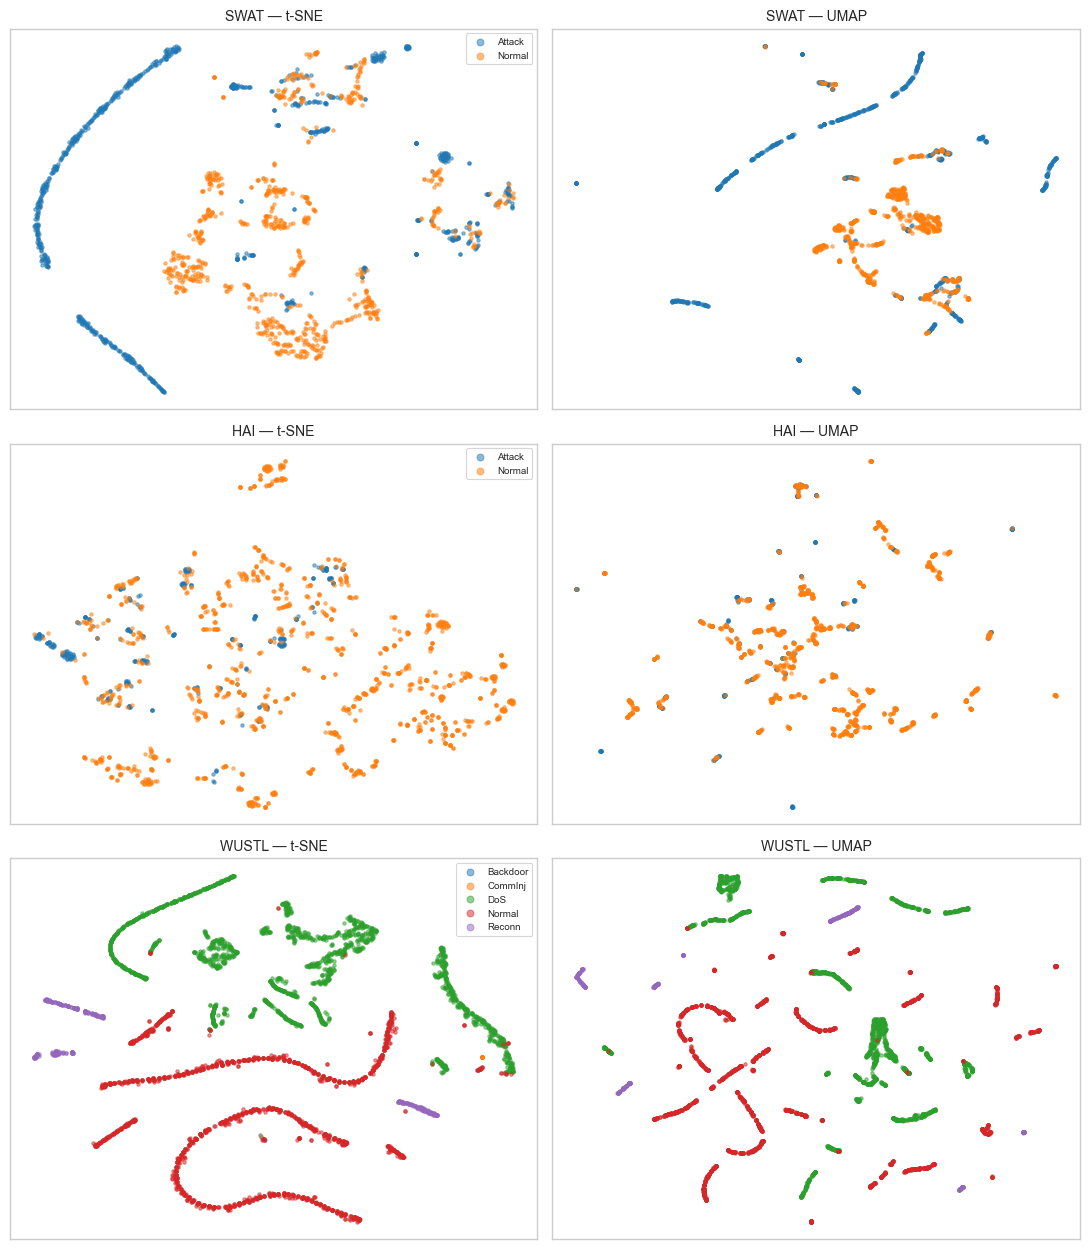

Saved REV-C embeddings figure.


In [22]:
# ============================================================
# REV-C — t-SNE + UMAP embeddings
# ============================================================
if RUN_REV_C_EMBEDDINGS:
    from sklearn.preprocessing import StandardScaler
    from sklearn.manifold import TSNE
    OUT=ensure_dir(os.path.join(BASE_OUT,"REV_C_embeddings"))
    try:
        import umap; HAVE_UMAP=True
    except Exception:
        HAVE_UMAP=False; print("umap-learn unavailable; UMAP column will be blank.")
    PER_CLASS=800; SEED=42
    specs=[("swat",True),("hai",True),("wustl",False)]
    fig,axes=plt.subplots(len(specs),2,figsize=(11,4.2*len(specs)))
    for r,(ds,binary) in enumerate(specs):
        df=load_processed(ds, binary=binary)
        feats=select_top_features(df,k=TOP_K_FEATURES,seed=SEED)
        samp=_stratified_subsample(df, PER_CLASS*df["Label"].nunique(), SEED)
        X=StandardScaler().fit_transform(samp[feats].values)
        y=samp["Label"].values; classes=sorted(set(y))
        pal=sns.color_palette("tab10", len(classes))
        cmap={c:pal[i] for i,c in enumerate(classes)}
        emb_tsne=TSNE(n_components=2,perplexity=30,init="pca",random_state=SEED).fit_transform(X)
        emb_umap=umap.UMAP(n_components=2,random_state=SEED).fit_transform(X) if HAVE_UMAP else None
        for c in classes:
            mask=y==c
            axes[r,0].scatter(emb_tsne[mask,0],emb_tsne[mask,1],s=6,alpha=0.5,
                              color=cmap[c],label=c)
            if emb_umap is not None:
                axes[r,1].scatter(emb_umap[mask,0],emb_umap[mask,1],s=6,alpha=0.5,
                                  color=cmap[c],label=c)
        axes[r,0].set_title(f"{ds.upper()} — t-SNE"); axes[r,0].legend(fontsize=7,markerscale=2)
        axes[r,1].set_title(f"{ds.upper()} — UMAP")
        for cax in (axes[r,0],axes[r,1]): cax.set_xticks([]); cax.set_yticks([])
    plt.tight_layout()
    plt.savefig(os.path.join(OUT,"revc_embeddings.png"),dpi=160,bbox_inches="tight")
    plt.savefig(os.path.join(OUT,"revc_embeddings.pdf"),bbox_inches="tight")
    plt.show()
    print("Saved REV-C embeddings figure.")
else:
    print("REV-C skipped.")

### REV-D (R2.5) — Complexity analysis

Consolidates per-method complexity: parameter count, on-disk model size,
fit/inference wall-time, peak memory, and an approximate FLOPs estimate. Tabular
anchors are measured directly; LLM figures combine published parameter counts
(total + active for the MoE) with the standard $\approx 2\!\times\!N_{active}$
FLOPs-per-token estimate and measured per-sample API latency.

In [23]:
# ============================================================
# REV-D — complexity table (params / size / time / memory / approx FLOPs)
# ============================================================
if RUN_REV_D_COMPLEXITY:
    OUT=ensure_dir(os.path.join(BASE_OUT,"REV_D_complexity"))
    rows=[]
    # ---- tabular anchors: measure on a representative dataset (WUSTL binary) ----
    df=load_processed("wustl", binary=True)
    feats=select_top_features(df,k=TOP_K_FEATURES,seed=42)
    icl,test=build_icl_test_split(df,feats,K_SHOT_PER_CLASS,n_test_per_class=5000,seed=42)
    n_test=len(test)
    for nm in ["RandomForest","XGBoost","TabPFN","TabICL"]:
        try:
            m=fit_anchor(nm,icl,test,feats)
            model=m["model_obj"]
            blob=pickle.dumps(model); size_mb=len(blob)/1e6
            # parameter / node proxy
            try:
                if nm=="RandomForest":
                    params=sum(t.tree_.node_count for t in model.estimators_)
                elif nm=="XGBoost":
                    params=int(model.get_booster().trees_to_dataframe().shape[0])
                else:
                    params=float("nan")  # FM checkpoints: see note column
            except Exception: params=float("nan")
            rows.append(dict(method=nm,family="tabular",total_params=params,
                active_params=params,size_mb=round(size_mb,3),
                fit_s=round(m["fit_s"],4),pred_s_per_1k=round(1000*m["pred_s"]/n_test,4),
                peak_mem_mb=round(m["peak_mem_mb"],2),
                approx_gflops_per_1k="tree-traversal (negligible)"))
        except Exception as e:
            print(f"  [skip] {nm}: {type(e).__name__}: {e}")
    # ---- LLMs: published params + approx FLOPs/token + measured latency (if key) ----
    AVG_TOKENS_PER_SAMPLE=420   # ~12 features x K_shot ICL prompt; adjust if needed
    for nm,meta in MODEL_META.items():
        gflops_per_sample=2*meta["active_b"]*1e9*AVG_TOKENS_PER_SAMPLE/1e9  # ~2*N_active*tokens
        latency_s=float("nan")
        if client is not None:
            try:
                sub=_stratified_subsample(test,40,42)
                t0=time.time(); _=run_llm(nm,icl,sub,feats,"wustl",verbose=False)
                latency_s=round((time.time()-t0)/len(sub),3)
            except Exception: pass
        rows.append(dict(method=nm,family="LLM",
            total_params=meta["size_b"]*1e9,active_params=meta["active_b"]*1e9,
            size_mb=round(meta["size_b"]*2*1000,1),   # bf16 ~2 bytes/param -> MB
            fit_s=0.0,pred_s_per_1k=(round(latency_s*1000,1) if latency_s==latency_s else float("nan")),
            peak_mem_mb="served (Nebius)",
            approx_gflops_per_1k=round(gflops_per_sample*1000,1)))
    comp=pd.DataFrame(rows); comp.to_csv(os.path.join(OUT,"revd_complexity.csv"),index=False)
    with open(os.path.join(OUT,"revd_complexity.tex"),"w") as f:
        f.write(comp.to_latex(index=False,escape=True))
    print(comp.to_string(index=False))
else:
    print("REV-D skipped.")

00:00 Fitting... Done!
00:11 Predicting... Done!
00:01 Predicting... Done!
         method  family  total_params  active_params    size_mb  fit_s  pred_s_per_1k     peak_mem_mb        approx_gflops_per_1k
   RandomForest tabular  9.640000e+02   9.640000e+02      0.139 0.5552         0.0026            3.19 tree-traversal (negligible)
        XGBoost tabular  6.000000e+02   6.000000e+02      0.163 0.0346         0.0001            0.26 tree-traversal (negligible)
         TabPFN tabular           NaN            NaN      0.003 0.4172         1.1537            3.06 tree-traversal (negligible)
         TabICL tabular           NaN            NaN      0.015 0.2568         3.1271           27.97 tree-traversal (negligible)
  Llama-3.3-70B     LLM  7.000000e+10   7.000000e+10 140000.000 0.0000        52.0000 served (Nebius)                  58800000.0
Qwen3-235B-A22B     LLM  2.350000e+11   2.200000e+10 470000.000 0.0000        40.0000 served (Nebius)                  18480000.0
   Hermes-4-70B

### REV-E (R1.2) — Cross-campaign generalisation (leave-one-attack-type-out)

The chronological-split analysis in the paper probes *within-run* detection.
This block adds a genuine **cross-repertoire** probe on WUSTL: for each attack
type $h$, the training/ICL set is built **excluding $h$ entirely** (the detector
has never seen that attack family), and the test set contains `Normal` + the
held-out $h$. We then measure the detector's ability to flag the unseen attack
as *some* anomaly (recall on $h$) and its `Normal` false-alarm rate. This is the
operational "novel attack repertoire" scenario the reviewer flags.

00:21 Fitting... Done!
00:10 Predicting... Done!
00:01 Predicting... Done!
00:05 Fitting... Done!
00:05 Predicting... Done!
00:01 Predicting... Done!
00:02 Fitting... Done!
00:03 Predicting... Done!
00:01 Predicting... Done!
00:01 Fitting... Done!
00:05 Predicting... Done!
00:01 Predicting... Done!
00:04 Fitting... Done!
00:06 Predicting... Done!
00:01 Predicting... Done!
00:04 Fitting... Done!
00:06 Predicting... Done!
00:01 Predicting... Done!
00:03 Fitting... Done!
00:05 Predicting... Done!
00:01 Predicting... Done!
00:03 Fitting... Done!
00:04 Predicting... Done!
00:01 Predicting... Done!
00:12 Fitting... Done!
00:07 Predicting... Done!
00:01 Predicting... Done!
00:03 Fitting... Done!
00:06 Predicting... Done!
00:01 Predicting... Done!
00:03 Fitting... Done!
00:10 Predicting... Done!
00:01 Predicting... Done!
00:01 Fitting... Done!
00:17 Predicting... Done!
00:01 Predicting... Done!
=== Unseen-attack detection recall (held-out attack never in training) ===
model     Qwen3-235B-A22B

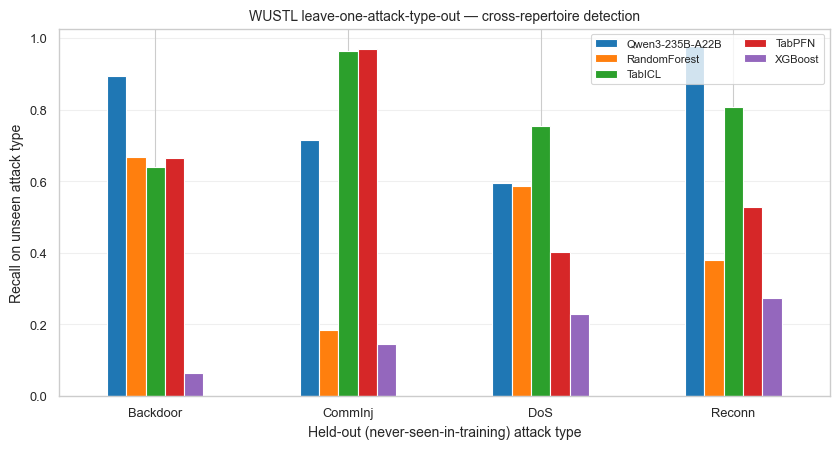

In [24]:
# ============================================================
# REV-E — leave-one-attack-type-out cross-campaign probe (WUSTL)
# ============================================================
if RUN_REV_E_CROSSCAMPAIGN:
    OUT=ensure_dir(os.path.join(BASE_OUT,"REV_E_crosscampaign"))
    ANCHORS_E=["RandomForest","XGBoost","TabPFN","TabICL"]
    HELDOUT=["DoS","Reconn","CommInj","Backdoor"]
    rows=[]
    for seed in SEEDS:
        df=load_processed("wustl", binary=False)
        feats=select_top_features(df,k=TOP_K_FEATURES,seed=seed)
        for h in HELDOUT:
            seen=df[df["Label"]!=h].copy()          # train: Normal + 3 other attacks
            # collapse seen attacks -> binary so the model learns "Normal vs Attack"
            seen_bin=seen.copy(); seen_bin["Label"]=np.where(seen_bin["Label"]=="Normal","Normal","Attack")
            icl,_=build_icl_test_split(seen_bin,feats,K_SHOT_PER_CLASS,seed=seed)
            # test: Normal (held-out rows) + the unseen attack h, labelled binary
            normal_pool=df[df["Label"]=="Normal"]
            h_pool=df[df["Label"]==h]
            rng=np.random.default_rng(seed)
            n_norm=min(len(normal_pool),4000); n_h=min(len(h_pool),2000)
            test=pd.concat([normal_pool.iloc[rng.choice(len(normal_pool),n_norm,replace=False)],
                            h_pool.iloc[rng.choice(len(h_pool),n_h,replace=False)]])
            test=test.copy(); test["Label"]=np.where(test["Label"]=="Normal","Normal","Attack")
            test=test.sample(frac=1,random_state=seed).reset_index(drop=True)
            for nm in ANCHORS_E:
                try:
                    m=fit_anchor(nm,icl,test,feats)
                    rows.append(dict(seed=seed,heldout=h,model=nm,
                        unseen_recall=m["detection_rate"],far=m["false_alarm_rate"],
                        mcc=m["mcc"],macro_f1=m["macro_f1"]))
                except Exception as e:
                    print(f"  [skip] heldout={h} {nm}: {type(e).__name__}")
            if REV_E_INCLUDE_LLM and client is not None:
                sub=_stratified_subsample(test,1000,seed)
                m=run_llm(PRIMARY_MODEL,icl,sub,feats,"wustl",verbose=False)
                rows.append(dict(seed=seed,heldout=h,model=PRIMARY_MODEL,
                    unseen_recall=m["detection_rate"],far=m["false_alarm_rate"],
                    mcc=m["mcc"],macro_f1=m["macro_f1"]))
    ce=pd.DataFrame(rows); ce.to_csv(os.path.join(OUT,"reve_crosscampaign.csv"),index=False)
    piv=ce.groupby(["heldout","model"])["unseen_recall"].mean().unstack().round(3)
    print("=== Unseen-attack detection recall (held-out attack never in training) ===")
    print(piv.to_string())
    # figure
    fig,ax=plt.subplots(figsize=(8.5,4.6))
    piv.plot(kind="bar",ax=ax); ax.set_ylabel("Recall on unseen attack type")
    ax.set_xlabel("Held-out (never-seen-in-training) attack type")
    ax.set_title("WUSTL leave-one-attack-type-out — cross-repertoire detection")
    ax.legend(fontsize=8,ncol=2); ax.grid(alpha=0.3,axis="y"); plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT,"reve_crosscampaign.png"),dpi=160,bbox_inches="tight")
    plt.savefig(os.path.join(OUT,"reve_crosscampaign.pdf"),bbox_inches="tight")
    plt.show()
else:
    print("REV-E skipped.")

### REV-F (R1.3) — Regenerate Figure 1 as a 2x2 panel, loaded from the repo archives

Reviewer 1 asked for the headline forest plot to be split into a legible 2x2
layout. This block rebuilds it **directly from the committed result archives** so
the figure is fully reproducible from the repo with no manual transcription:

* `RandomForest`, `TabPFN`, `TabICL`, and the primary LLM come from each
  dataset's `runs/<slug>_binary.zip` -> `E7_full_test/e7_multiseed_summary_<slug>.csv`
  (mean and standard deviation already aggregated over the three seeds).
* `XGBoost` comes from `runs/supplementary/xgboost_anchor_e7.zip` ->
  `xgb_master_summary.csv` (per-seed rows, filtered to the binary task and
  aggregated here).

Set `REPO_ROOT` in the CONFIG cell to the repo root before running. Outputs
`fig_forest_headline_2x2.pdf/.png`; FAR keeps its separate Pareto figure.


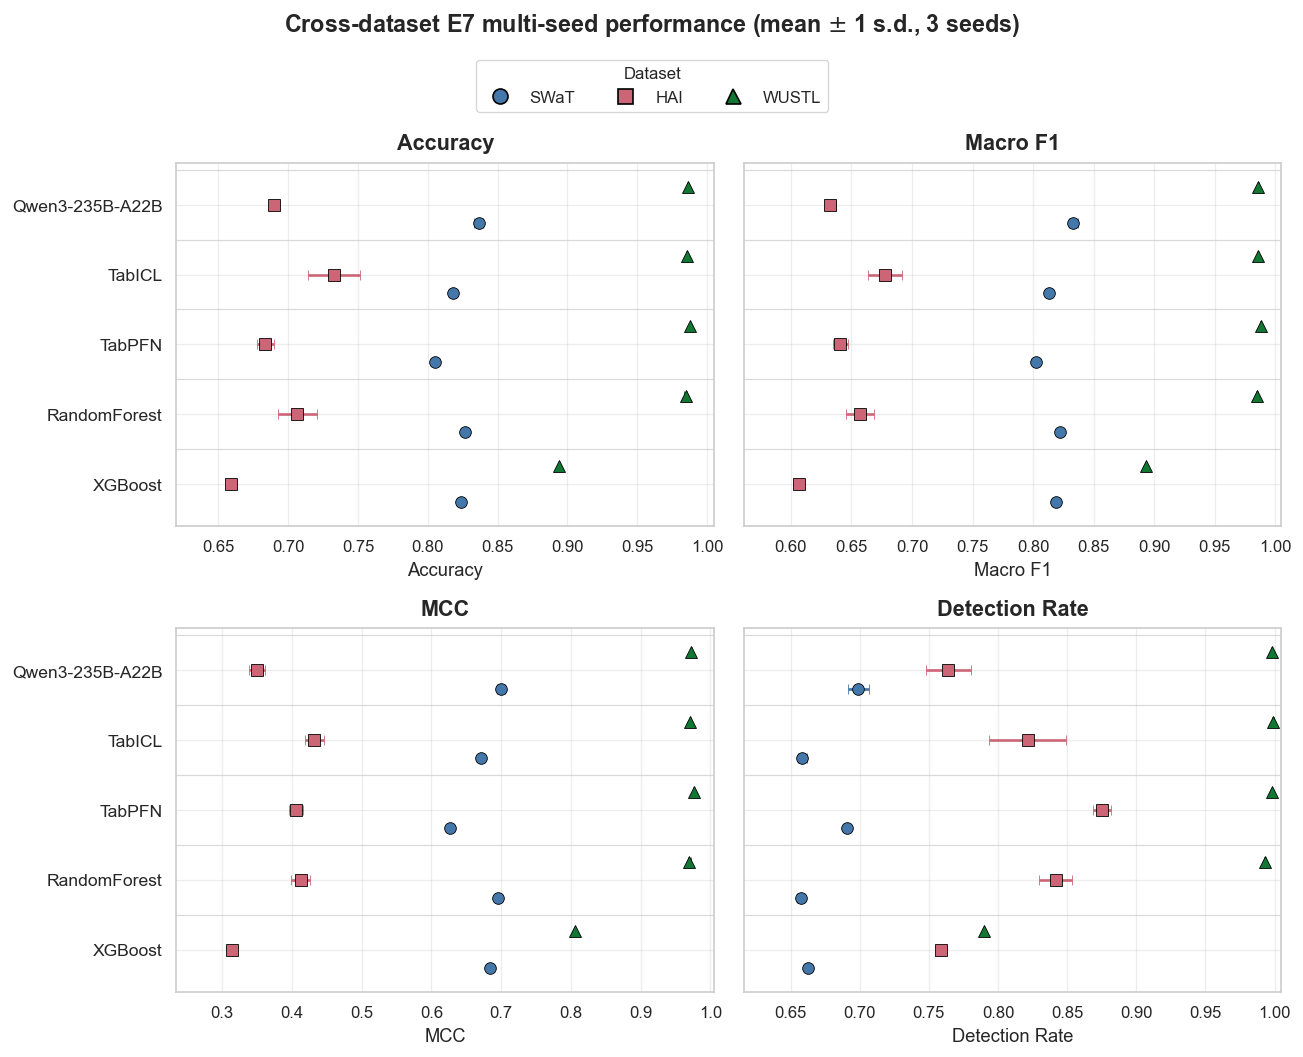

REV-F done -> ./ot_ics_ids_revision_outputs/REV_F_figure1


In [25]:
# ============================================================
# REV-F — rebuild Figure 1 (2x2 headline) from the repo result archives
# ============================================================
def _read_zip_csv(zip_path, member):
    """Read a CSV stored inside a zip; fall back to basename match."""
    with zipfile.ZipFile(zip_path) as z:
        names = z.namelist()
        if member not in names:
            cand = [n for n in names if n.endswith(os.path.basename(member))]
            if not cand:
                raise FileNotFoundError(f"{member!r} not found in {zip_path}")
            member = cand[0]
        return pd.read_csv(io.BytesIO(z.read(member)))

if RUN_REV_F_FIG1:
    import io
    RUNS_DIR = os.path.join(REPO_ROOT, "runs")
    OUT_F    = ensure_dir(os.path.join(BASE_OUT, "REV_F_figure1"))

    DS_SLUG   = {"SWaT": "swat", "HAI": "hai", "WUSTL": "wustl"}
    E7_MEMBER = ("ot_ics_ids_llm_nebius_v1_outputs/E7_full_test/"
                 "e7_multiseed_summary_{slug}.csv")
    COLMAP    = {"acc": "accuracy", "mf1": "macro_f1", "mcc": "MCC", "dr": "DR"}

    # --- 1) RF / TabPFN / TabICL / LLM from the per-dataset binary archives ---
    DATA = {ds: {} for ds in DS_SLUG}
    for ds, slug in DS_SLUG.items():
        df = _read_zip_csv(os.path.join(RUNS_DIR, f"{slug}_binary.zip"),
                           E7_MEMBER.format(slug=slug)).set_index("model")
        for m in ["RandomForest", "TabPFN", "TabICL", PRIMARY_MODEL]:
            r = df.loc[m]
            DATA[ds][m] = {k: (float(r[f"{c}_mean"]), float(r[f"{c}_std"]))
                           for k, c in COLMAP.items()}

    # --- 2) XGBoost from the supplementary anchor archive (per-seed -> mean/std) ---
    xgb = _read_zip_csv(os.path.join(RUNS_DIR, "supplementary", "xgboost_anchor_e7.zip"),
                        "xgb_master_summary.csv")
    xgb_bin = xgb[xgb["task"] == "binary"]
    for ds, slug in DS_SLUG.items():
        sub = xgb_bin[xgb_bin["dataset"] == slug]
        if len(sub) == 0:
            raise ValueError(f"No XGBoost binary rows for {slug} in xgb_master_summary.csv")
        DATA[ds]["XGBoost"] = {k: (float(sub[c].mean()), float(sub[c].std(ddof=0)))
                               for k, c in COLMAP.items()}

    # --- 3) plot 2x2 ---
    METRICS   = [("acc", "Accuracy"), ("mf1", "Macro F1"),
                 ("mcc", "MCC"), ("dr", "Detection Rate")]
    MODELS    = ["XGBoost", "RandomForest", "TabPFN", "TabICL", PRIMARY_MODEL]
    DATASETS  = ["SWaT", "HAI", "WUSTL"]
    DS_COLOR  = {"SWaT": "#4477AA", "HAI": "#CC6677", "WUSTL": "#117733"}  # Tol, CB-safe
    DS_MARKER = {"SWaT": "o", "HAI": "s", "WUSTL": "^"}

    with plt.rc_context({
        "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
        "xtick.labelsize": 10, "ytick.labelsize": 10.5, "legend.fontsize": 10,
        "axes.grid": True, "grid.alpha": 0.35, "axes.axisbelow": True, "figure.dpi": 120,
    }):
        fig, axes = plt.subplots(2, 2, figsize=(11.0, 8.4), sharey=True)
        axes = axes.ravel()
        offsets = np.linspace(-0.26, 0.26, len(DATASETS))
        for ai, (mk, ml) in enumerate(METRICS):
            ax = axes[ai]
            for yi, model in enumerate(MODELS):
                for di, ds in enumerate(DATASETS):
                    mean, std = DATA[ds][model][mk]
                    ax.errorbar(mean, yi + offsets[di], xerr=std,
                                fmt=DS_MARKER[ds], color=DS_COLOR[ds], markersize=7,
                                markeredgecolor="black", markeredgewidth=0.5,
                                elinewidth=1.6, capsize=3, capthick=1.4, zorder=3)
            ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(MODELS)
            ax.set_xlabel(ml); ax.set_title(ml, fontweight="bold", pad=8)
            ax.set_ylim(-0.6, len(MODELS) - 0.4)
            for yi in range(len(MODELS)):
                ax.axhline(yi + 0.5, color="0.85", lw=0.7, zorder=0)
            allv = [DATA[ds][m][mk][0] for ds in DATASETS for m in MODELS]
            lo, hi = min(allv), max(allv); pad = max(0.02, (hi - lo) * 0.12)
            ax.set_xlim(lo - pad, min(1.005, hi + pad))
        handles = [plt.Line2D([0], [0], marker=DS_MARKER[ds], color="w",
                              markerfacecolor=DS_COLOR[ds], markeredgecolor="black",
                              markersize=9, label=ds) for ds in DATASETS]
        fig.legend(handles=handles, loc="upper center", ncol=3, frameon=True,
                   bbox_to_anchor=(0.5, 1.005), title="Dataset")
        fig.suptitle("Cross-dataset E7 multi-seed performance "
                     r"(mean $\pm$ 1 s.d., 3 seeds)",
                     y=1.045, fontsize=14, fontweight="bold")
        fig.tight_layout(rect=[0, 0, 1, 0.99])
        out = os.path.join(OUT_F, "fig_forest_headline_2x2")
        fig.savefig(out + ".pdf", bbox_inches="tight")
        fig.savefig(out + ".png", dpi=200, bbox_inches="tight")
        plt.show()

    # also dump the assembled numbers as a tidy CSV for the response letter
    rows = [{"dataset": ds, "model": m, "metric": k, "mean": v[0], "std": v[1]}
            for ds in DATASETS for m in MODELS for k, v in DATA[ds][m].items()]
    pd.DataFrame(rows).to_csv(os.path.join(OUT_F, "fig1_values.csv"), index=False)
    print("REV-F done ->", OUT_F)
else:
    print("REV-F skipped (RUN_REV_F_FIG1=False)")


## PART 3 — Package the revision artifacts

In [26]:
# ============================================================
# Bundle all REV-* outputs into a single archive for the repo
# ============================================================
zip_path="./revision_experiments_outputs.zip"
with zipfile.ZipFile(zip_path,"w",zipfile.ZIP_DEFLATED) as z:
    for root,_,files in os.walk(BASE_OUT):
        for fn in files:
            full=os.path.join(root,fn)
            z.write(full, os.path.relpath(full, os.path.dirname(BASE_OUT)))
print("Wrote", zip_path)
print("Place it under runs/supplementary/ in the fm-security repo.")

Wrote ./revision_experiments_outputs.zip
Place it under runs/supplementary/ in the fm-security repo.


## PART 4 — Download the bundled archive (Colab)

Run after the packaging cell. Triggers a browser download of the zip; if the
automatic download fails, use the fallback hint to grab it from the Files panel.


In [27]:
# ============================================================
# Force-download the bundled archive from Colab
# ============================================================
zip_path = "./revision_experiments_outputs.zip"   # written by the packaging cell

if not os.path.exists(zip_path):
    raise FileNotFoundError(f"{zip_path} not found -- run the packaging cell first")

print(f"Archive: {zip_path}  ({os.path.getsize(zip_path)/1e6:.2f} MB)")
try:
    from google.colab import files
    files.download(zip_path)
    print("Download triggered. Check your browser's downloads.")
except Exception as e:
    # Not on Colab (e.g. local JupyterLab) or the browser download failed.
    abspath = os.path.abspath(zip_path)
    print(f"Browser download unavailable ({type(e).__name__}).")
    print(f"The archive is on disk at:\n  {abspath}")
    print("On Colab: open the Files panel (folder icon) and download it from there.\n"
          "Locally (JupyterLab/Mac): copy it from the path above, or in JupyterLab "
          "right-click the file in the browser and choose Download.")


Archive: ./revision_experiments_outputs.zip  (1.21 MB)
Browser download unavailable (ModuleNotFoundError).
The archive is on disk at:
  /Users/dezarzaycubero/Downloads/colab_dezarza/ot_ics/revision_experiments_outputs.zip
On Colab: open the Files panel (folder icon) and download it from there.
Locally (JupyterLab/Mac): copy it from the path above, or in JupyterLab right-click the file in the browser and choose Download.
